# Gunshot Audio Classification

In [1]:
import os
import soundfile as sf
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


In [2]:
import wave as wave_module
import numpy as np

def load_wav_info(file_path):
    with wave_module.open(str(file_path), 'rb') as wf:
        sr = wf.getframerate()
        ch = wf.getnchannels()
        n_frames = wf.getnframes()
        b = wf.readframes(n_frames)
        w = torch.from_numpy(np.frombuffer(b, dtype=np.int16).copy()).float()
        w = w.view(-1, ch).T / 32768.0
    return w, sr

In [3]:
# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory allocated: {torch.cuda.memory_allocated(0)/1e9:.2f} GB')
else:
    print('WARNING: No GPU found, training on CPU — this will be slow')

GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Memory allocated: 0.00 GB


In [5]:
# Explore the dataset structure and count files per class
dataset_path = Path('../gunshot-audio-dataset')
class_names = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])

print('Dataset classes:')
for class_name in class_names:
    class_path = dataset_path / class_name
    file_count = len(list(class_path.glob('*.wav')))
    print(f'  {class_name}: {file_count} files')

Dataset classes:
  AK-12: 98 files
  AK-47: 72 files
  IMI Desert Eagle: 100 files
  M16: 100 files
  M249: 99 files
  M4: 100 files
  MG-42: 100 files
  MP5: 100 files
  Zastava M92: 82 files


In [6]:
# Check channels across all 851 files
mono_count = 0
stereo_count = 0

for class_name in class_names:
    class_path = dataset_path / class_name
    audio_files = list(class_path.glob('*.wav'))
    for audio_file in audio_files:
        waveform, sr = load_wav_info(audio_file)
        channels = waveform.shape[0]
        if channels == 1:
            mono_count += 1
        else:
            stereo_count += 1

print(f'Mono files: {mono_count}')
print(f'Stereo files: {stereo_count}')

Mono files: 0
Stereo files: 851


In [7]:
# Check sample rates across all 851 files
sample_rate_counts = {}

for class_name in class_names:
    class_path = dataset_path / class_name
    audio_files = list(class_path.glob('*.wav'))
    for audio_file in audio_files:
        waveform, sr = load_wav_info(audio_file)
        if sr not in sample_rate_counts:
            sample_rate_counts[sr] = 0
        sample_rate_counts[sr] += 1

for sr, count in sorted(sample_rate_counts.items()):
    print(f'{sr} Hz: {count} files')

44100 Hz: 197 files
48000 Hz: 654 files


In [8]:
# Check class imbalance across all audio files
class_file_counts = {}

for class_name in class_names:
    class_path = dataset_path / class_name
    file_count = len(list(class_path.glob('*.wav')))
    class_file_counts[class_name] = file_count

max_count = max(class_file_counts.values())
min_count = min(class_file_counts.values())

print('Class distribution:')
for class_name, count in class_file_counts.items():
    print(f'  {class_name}: {count} files')

if max_count > 2 * min_count:
    print(f'\nClass imbalance detected: max={max_count}, min={min_count}')


Class distribution:
  AK-12: 98 files
  AK-47: 72 files
  IMI Desert Eagle: 100 files
  M16: 100 files
  M249: 99 files
  M4: 100 files
  MG-42: 100 files
  MP5: 100 files
  Zastava M92: 82 files


In [9]:
# Define individual preprocessing functions
def convert_to_mono(waveform):
    if waveform.shape[0] > 1:
        return torch.mean(waveform, dim=0, keepdim=True)
    return waveform

def resample_audio(waveform, orig_sr, target_sr=48000):
    if orig_sr != target_sr:
        resampler = T.Resample(orig_sr, target_sr)
        return resampler(waveform)
    return waveform

def pad_or_crop(waveform, target_length):
    current_length = waveform.shape[1]
    if current_length < target_length:
        padding = target_length - current_length
        waveform = torch.nn.functional.pad(waveform, (0, padding))
    elif current_length > target_length:
        waveform = waveform[:, :target_length]
    return waveform

def apply_preemphasis(waveform, coef=0.97):
    return torch.cat([waveform[:, :1], waveform[:, 1:] - coef * waveform[:, :-1]], dim=1)

def normalize_audio(waveform):
    return waveform / (torch.max(torch.abs(waveform)) + 1e-8)

In [10]:
# Preprocessing pipeline that applies all transformations
def preprocess_audio(file_path, target_sr=48000, target_duration=2.0):
    waveform, sr = load_wav_info(file_path)
    waveform = convert_to_mono(waveform)
    waveform = resample_audio(waveform, sr, target_sr)
    target_length = int(target_sr * target_duration)
    waveform = pad_or_crop(waveform, target_length)
    waveform = apply_preemphasis(waveform)
    waveform = normalize_audio(waveform)
    return waveform, target_sr

In [11]:
# Process all audio files and save to processed-audio-48k folder
output_path = Path('processed-audio-48k')
output_path.mkdir(exist_ok=True)

print('Preprocessing audio files...')
for class_name in class_names:
    class_output_path = output_path / class_name
    class_output_path.mkdir(exist_ok=True)
    
    class_input_path = dataset_path / class_name
    audio_files = list(class_input_path.glob('*.wav'))
    
    for audio_file in audio_files:
        waveform, sr = preprocess_audio(audio_file)
        output_file = class_output_path / audio_file.name
        sf.write(str(output_file), waveform.squeeze(0).numpy(), sr)
    
    print(f'  Processed {len(audio_files)} files for {class_name}')

print('Preprocessing complete')

Preprocessing audio files...
  Processed 98 files for AK-12
  Processed 72 files for AK-47
  Processed 100 files for IMI Desert Eagle
  Processed 100 files for M16
  Processed 99 files for M249
  Processed 100 files for M4
  Processed 100 files for MG-42
  Processed 100 files for MP5
  Processed 82 files for Zastava M92
Preprocessing complete


In [12]:
# Extract MFCC features and save as tensors
features_path = Path('features')
features_path.mkdir(exist_ok=True)

mfcc_transform = T.MFCC(
    sample_rate=48000,
    n_mfcc=40,
    melkwargs={'n_fft': 1024, 'hop_length': 512, 'n_mels': 64}
)

print('Extracting MFCC features...')
for class_name in class_names:
    class_features_path = features_path / class_name
    class_features_path.mkdir(exist_ok=True)
    
    class_processed_path = output_path / class_name
    audio_files = list(class_processed_path.glob('*.wav'))
    
    for audio_file in audio_files:
        waveform, sr = load_wav_info(audio_file)
        mfcc = mfcc_transform(waveform)
        
        feature_file = class_features_path / f'{audio_file.stem}.pt'
        torch.save(mfcc, feature_file)
    
    print(f'  Extracted features for {len(audio_files)} files in {class_name}')

print('Feature extraction complete')

Extracting MFCC features...
  Extracted features for 98 files in AK-12
  Extracted features for 72 files in AK-47
  Extracted features for 100 files in IMI Desert Eagle
  Extracted features for 100 files in M16
  Extracted features for 99 files in M249
  Extracted features for 100 files in M4
  Extracted features for 100 files in MG-42
  Extracted features for 100 files in MP5
  Extracted features for 82 files in Zastava M92
Feature extraction complete


In [13]:
# Define class mapping with M16 and M4 merged into M-Family
class_to_idx = {
    'AK-12': 0,
    'AK-47': 1,
    'IMI Desert Eagle': 2,
    'M16': 3,
    'M4': 3,
    'M249': 4,
    'MG-42': 5,
    'MP5': 6,
    'Zastava M92': 7
}

idx_to_class = {
    0: 'AK-12',
    1: 'AK-47',
    2: 'IMI Desert Eagle',
    3: 'M-Family',
    4: 'M249',
    5: 'MG-42',
    6: 'MP5',
    7: 'Zastava M92'
}

print('Class mapping:')
for class_name, idx in class_to_idx.items():
    print(f'  {class_name} → {idx}')

Class mapping:
  AK-12 → 0
  AK-47 → 1
  IMI Desert Eagle → 2
  M16 → 3
  M4 → 3
  M249 → 4
  MG-42 → 5
  MP5 → 6
  Zastava M92 → 7


In [14]:
# Define dataset class for loading MFCC features
class GunshotDataset(Dataset):
    def __init__(self, features_path, class_to_idx, augment=False):
        self.features_path = Path(features_path)
        self.class_to_idx = class_to_idx
        self.augment = augment
        self.samples = []
        
        for class_name in class_to_idx.keys():
            class_path = self.features_path / class_name
            if class_path.exists():
                for feature_file in class_path.glob('*.pt'):
                    self.samples.append((feature_file, class_to_idx[class_name]))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        feature_file, label = self.samples[idx]
        features = torch.load(feature_file, weights_only=True)
        
        if self.augment:
            
            # Gaussian noise (40% probability)
            if torch.rand(1).item() > 0.6:
                features = features + torch.randn_like(features) * 0.01

            # Time shift (40% probability)
            if torch.rand(1).item() > 0.6:
                shift = torch.randint(-10, 11, (1,)).item()
                features = torch.roll(features, shifts=shift, dims=-1)

            # Frequency masking — SpecAugment (50% probability)
            if torch.rand(1).item() > 0.5:
                freq_mask = T.FrequencyMasking(freq_mask_param=8)
                features = freq_mask(features)

            # Time masking — SpecAugment (50% probability)
            if torch.rand(1).item() > 0.5:
                time_mask = T.TimeMasking(time_mask_param=15)
                features = time_mask(features)
        
        return features, label

full_dataset = GunshotDataset('features', class_to_idx, augment=False)
print(f'Total samples: {len(full_dataset)}')

Total samples: 851


In [15]:
# Compute class counts from unaugmented dataset to avoid augmentation interference
class_counts = torch.zeros(8)
for _, label in GunshotDataset('features', class_to_idx, augment=False):
    class_counts[label] += 1

class_weights = 1.0 / class_counts.clamp(min=1)
class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to(device)
print('Class counts:', class_counts.int().tolist())
print('Class weights:', class_weights.cpu().numpy().round(4))

Class counts: [98, 72, 100, 200, 99, 100, 100, 82]
Class weights: [0.1254 0.1706 0.1229 0.0614 0.1241 0.1229 0.1229 0.1498]


In [16]:
from sklearn.model_selection import train_test_split
from torch.utils.data import WeightedRandomSampler

torch.manual_seed(42)

# Get all labels for stratified splitting
all_samples = GunshotDataset('features', class_to_idx, augment=False).samples
all_indices = list(range(len(all_samples)))
all_labels  = [label for _, label in all_samples]

# Stratified train / temp split (70 / 30)
train_indices, temp_indices, train_labels, temp_labels = train_test_split(
    all_indices, all_labels, test_size=0.30, stratify=all_labels, random_state=42
)

# Stratified val / test split (15 / 15 of total = 50 / 50 of temp)
val_indices, test_indices = train_test_split(
    temp_indices, test_size=0.50, stratify=temp_labels, random_state=42
)

# Build datasets
base_dataset     = GunshotDataset('features', class_to_idx, augment=False)
augment_dataset  = GunshotDataset('features', class_to_idx, augment=True)

train_dataset = torch.utils.data.Subset(augment_dataset, train_indices)
val_dataset   = torch.utils.data.Subset(base_dataset, val_indices)
test_dataset  = torch.utils.data.Subset(base_dataset, test_indices)

# WeightedRandomSampler for balanced batches during training
train_labels_list  = [all_labels[i] for i in train_indices]
sample_weights     = [1.0 / class_counts[label].item() for label in train_labels_list]
sampler            = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f'Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}')

Train: 595, Val: 128, Test: 128


In [17]:
# CNN architecture with two conv blocks and a fully connected head
class GunshotCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(GunshotCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [18]:
# Instantiate model, move to device, print trainable parameter count
model = GunshotCNN(num_classes=8).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total: {total_params:,}  Trainable: {trainable:,}')


Total: 564,232  Trainable: 564,232


In [19]:
# Weighted cross-entropy loss, Adam optimizer, cosine annealing scheduler
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=2e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)


In [20]:
# Training hyperparameters and empty history lists
num_epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []


In [21]:
# Training loop with early stopping — saves best model to best of the best.pth
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step()

    print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% - LR: {optimizer.param_groups[0]["lr"]:.6f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best of the best.pth')
        print(f'  Model saved with val_loss: {val_loss:.4f}')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

print('Training complete')


Epoch 1/50 - Train Loss: 1.7887, Train Acc: 27.06% - Val Loss: 1.5779, Val Acc: 37.50% - LR: 0.000500
  Model saved with val_loss: 1.5779
Epoch 2/50 - Train Loss: 1.3056, Train Acc: 41.34% - Val Loss: 1.3419, Val Acc: 43.75% - LR: 0.000498
  Model saved with val_loss: 1.3419
Epoch 3/50 - Train Loss: 1.2206, Train Acc: 45.38% - Val Loss: 1.1725, Val Acc: 46.88% - LR: 0.000496
  Model saved with val_loss: 1.1725
Epoch 4/50 - Train Loss: 1.0819, Train Acc: 51.93% - Val Loss: 1.1606, Val Acc: 47.66% - LR: 0.000492
  Model saved with val_loss: 1.1606
Epoch 5/50 - Train Loss: 0.9536, Train Acc: 59.50% - Val Loss: 1.0427, Val Acc: 50.00% - LR: 0.000488
  Model saved with val_loss: 1.0427
Epoch 6/50 - Train Loss: 0.9332, Train Acc: 58.99% - Val Loss: 1.0914, Val Acc: 46.88% - LR: 0.000482
Epoch 7/50 - Train Loss: 0.8788, Train Acc: 62.69% - Val Loss: 0.9475, Val Acc: 50.78% - LR: 0.000476
  Model saved with val_loss: 0.9475
Epoch 8/50 - Train Loss: 0.8726, Train Acc: 61.18% - Val Loss: 1.0776,

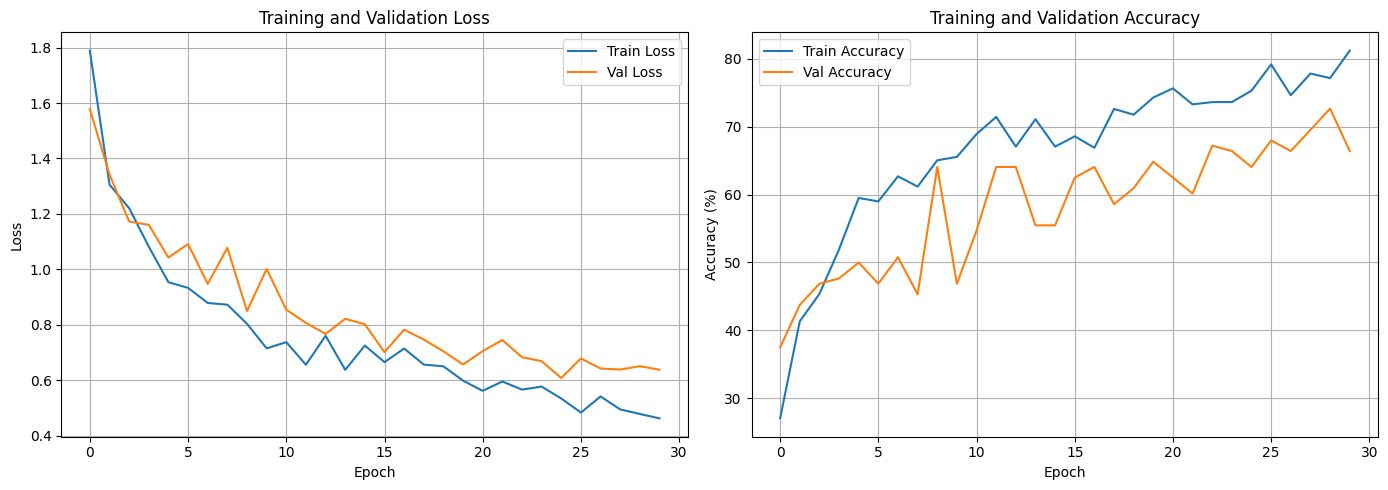

In [22]:
# Plot training and validation loss and accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accuracies, label='Train Accuracy')
ax2.plot(val_accuracies, label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


In [23]:
# Load best weights and evaluate on validation set
model.load_state_dict(torch.load('best of the best.pth', weights_only=True))
model.eval()

val_preds = []
val_labels = []

with torch.no_grad():
    for features, labels in val_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        _, predicted = torch.max(outputs, 1)
        val_preds.extend(predicted.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())

print('Validation Set Classification Report:\n')
print(classification_report(val_labels, val_preds, target_names=[idx_to_class[i] for i in range(8)]))


Validation Set Classification Report:

                  precision    recall  f1-score   support

           AK-12       1.00      1.00      1.00        14
           AK-47       1.00      1.00      1.00        11
IMI Desert Eagle       0.48      0.73      0.58        15
        M-Family       0.75      0.30      0.43        30
            M249       0.64      0.47      0.54        15
           MG-42       0.55      0.80      0.65        15
             MP5       0.23      0.33      0.27        15
     Zastava M92       1.00      1.00      1.00        13

        accuracy                           0.64       128
       macro avg       0.70      0.70      0.68       128
    weighted avg       0.69      0.64      0.64       128



In [24]:
# Evaluate on test set and store final test accuracy
model.eval()

test_correct = 0
test_total = 0
test_preds = []
test_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * test_correct / test_total
print(f'Test Accuracy: {test_accuracy:.2f}%\n')
print('Test Set Classification Report:\n')
print(classification_report(test_labels, test_preds, target_names=[idx_to_class[i] for i in range(8)]))


Test Accuracy: 73.44%

Test Set Classification Report:

                  precision    recall  f1-score   support

           AK-12       1.00      1.00      1.00        15
           AK-47       1.00      0.91      0.95        11
IMI Desert Eagle       0.50      0.73      0.59        15
        M-Family       0.83      0.50      0.62        30
            M249       0.67      0.53      0.59        15
           MG-42       0.64      0.93      0.76        15
             MP5       0.53      0.60      0.56        15
     Zastava M92       1.00      1.00      1.00        12

        accuracy                           0.73       128
       macro avg       0.77      0.78      0.76       128
    weighted avg       0.77      0.73      0.73       128



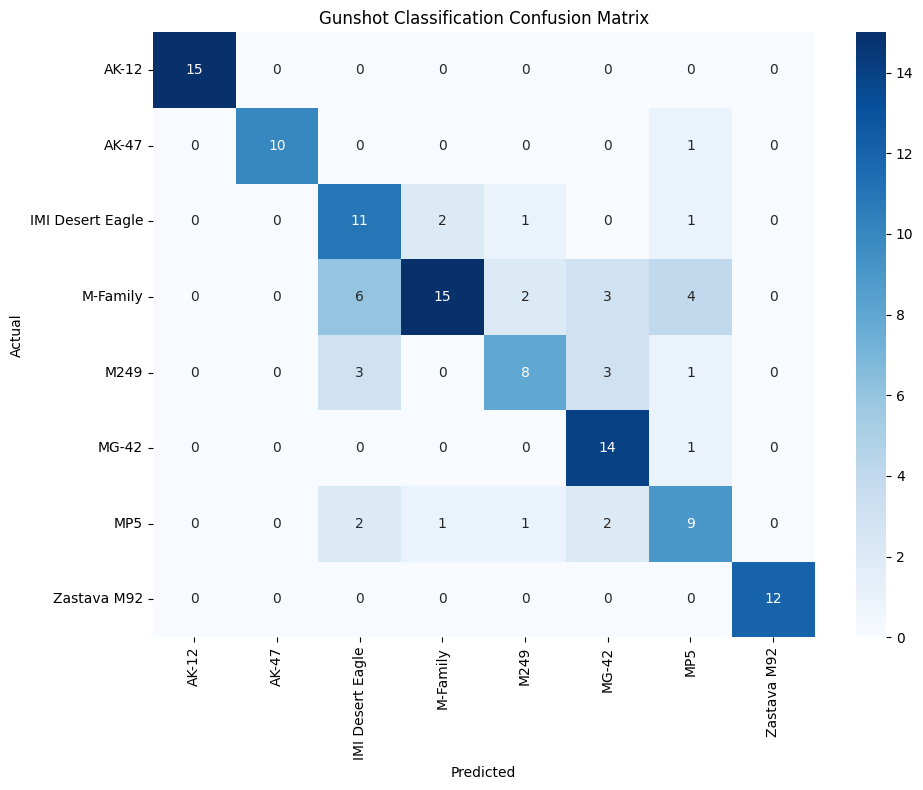

In [25]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[idx_to_class[i] for i in range(8)],
            yticklabels=[idx_to_class[i] for i in range(8)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Gunshot Classification Confusion Matrix')
plt.tight_layout()
plt.show()

In [26]:
# Final accuracy summary
print('Train Accuracy:     {:.2f}%'.format(train_accuracies[-1]))
print('Val Accuracy:       {:.2f}%'.format(val_accuracies[-1]))
print('Test Accuracy:      {:.2f}%'.format(test_accuracy))

Train Accuracy:     81.18%
Val Accuracy:       66.41%
Test Accuracy:      73.44%


In [27]:
import pickle

preprocessing_config = {
    "target_sr": 48000,
    "target_sec": 2,
    "pre_emphasis_coeff": 0.97,
    "n_mfcc": 40,
    "n_fft": 1024,
    "hop_length": 512,
    "n_mels": 64,
    "noise_gate_threshold": 0.0  # not used in this pipeline but kept for consistency
}

class_mapping = {
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class
}

with open("preprocessing_config.pkl", "wb") as f:
    pickle.dump(preprocessing_config, f)

with open("class_mapping.pkl", "wb") as f:
    pickle.dump(class_mapping, f)

print("[+] preprocessing_config.pkl saved")
print("[+] class_mapping.pkl saved")

[+] preprocessing_config.pkl saved
[+] class_mapping.pkl saved
